# Decision Tree (DT)
Decision Trees zijn een veelgebruikte machine learning-techniek voor zowel classificatie- als regressietaken. Ze werken door het opdelen van de dataset in kleinere subsets op basis van de waarden van de inputfeatures, waardoor een boomstructuur ontstaat waarin elke interne knoop een feature vertegenwoordigt, elke tak een beslissingsregel en elk blad een uitkomst (klasse of waarde). Decision Trees zijn intuïtief en gemakkelijk te interpreteren, wat ze populair maakt voor verschillende toepassingen. Echter, ze kunnen ook vatbaar zijn voor overfitting, vooral bij diepe bomen, wat kan leiden tot slechte generalisatie op nieuwe, ongeziene data. Om dit te voorkomen, worden vaak technieken zoals pruning, het instellen van een maximale diepte of het vereisen van een minimum aantal monsters per blad gebruikt.

![Voorbeeld Decision Tree](../assets/images/decision%20tree%20voorbeeld.png)

Bron: `https://www.researchgate.net/figure/Structure-of-Decision-Tree-Algorithm_fig3_370770672`

In [11]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Decision Tree analysis libraries imported successfully!")

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.normalization_functions import Normalizer
from utils.libs_generic_functions import LibsDataPreprocessor
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis

Decision Tree analysis libraries imported successfully!


In [2]:
%%time
df = pd.read_csv("../data/csv/processed_data.csv")

CPU times: total: 45.9 s
Wall time: 48.7 s


In [3]:
%%time
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df) 

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 6702)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 6702)
Test dataset shape: (10291, 6702)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 6699 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 6699)
Test features shape: (10291, 6699)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]
CPU times: total

# Comprehensive Decision Tree Analysis
In deze sectie voeren we een uitgebreide Decision Tree analyse uit, vergelijkbaar met onze KNN analyse. We testen verschillende configuraties en vergelijken de prestaties met en zonder dimensionaliteitsreductie.

DECISION TREE DATA PREPROCESSING
Training set shape: (41162, 6699)
Test set shape: (10291, 6699)
Applying SNV normalization to dataset:
  - Samples: 41162
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Applying SNV normalization to dataset:
  - Samples: 10291
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Data preprocessing completed!


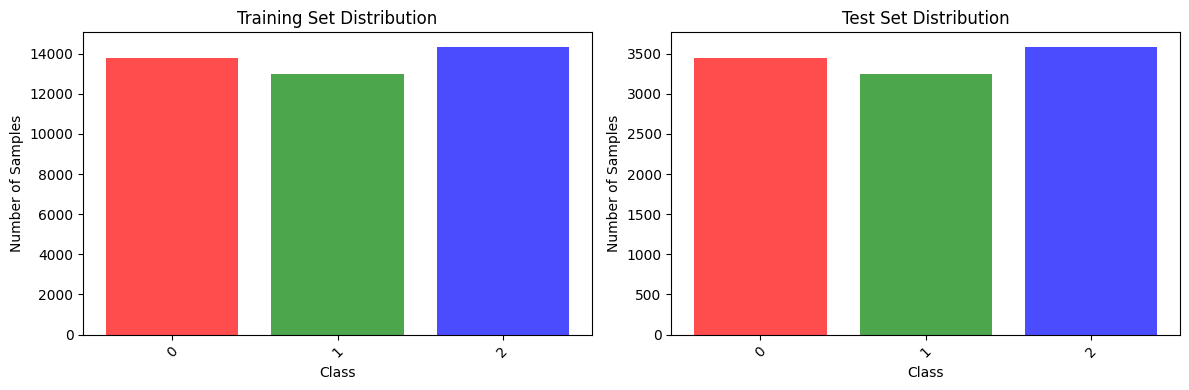


Label encoder mapping:
  innerliner → 0
  sidewall → 1
  tread → 2


In [4]:
# Data Preprocessing for Decision Tree Analysis
print("=" * 70)
print("DECISION TREE DATA PREPROCESSING")
print("=" * 70)


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Note: Decision Trees don't require feature scaling, but we'll prepare both scaled and unscaled versions
# for comparison with dimensionality reduction techniques

# Unscaled version (original Decision Tree)
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# Scaled version (for PCA/LDA comparison)
normalizer = Normalizer()
X_train_scaled = normalizer.apply_standard_normal_variate_on_dataset(X_train)
X_test_scaled = normalizer.apply_standard_normal_variate_on_dataset(X_test)

print("Data preprocessing completed!")

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train_encoded, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(train_unique, rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test_encoded, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(test_unique, rotation=45)

plt.tight_layout()
plt.show()

print(f"\nLabel encoder mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} → {i}")

1. DECISION TREE ON ORIGINAL FEATURES
Performing hyperparameter tuning with GridSearchCV...
Fitting 2 folds for each of 36 candidates, totalling 72 fits

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.8962

Decision Tree Accuracy on Original Features: 0.3354

Classification Report (Original Features):
              precision    recall  f1-score   support

  innerliner       0.34      1.00      0.50      3452
    sidewall       0.00      0.00      0.00      3252
       tread       0.00      0.00      0.00      3587

    accuracy                           0.34     10291
   macro avg       0.11      0.33      0.17     10291
weighted avg       0.11      0.34      0.17     10291



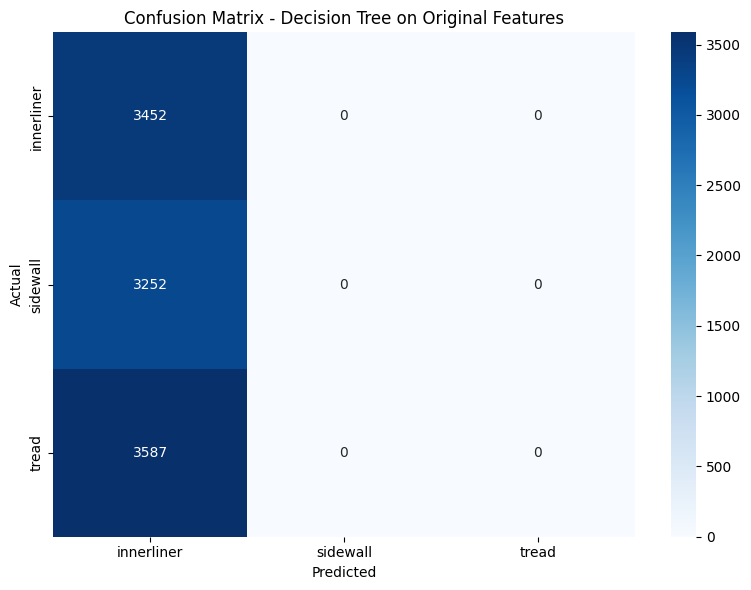

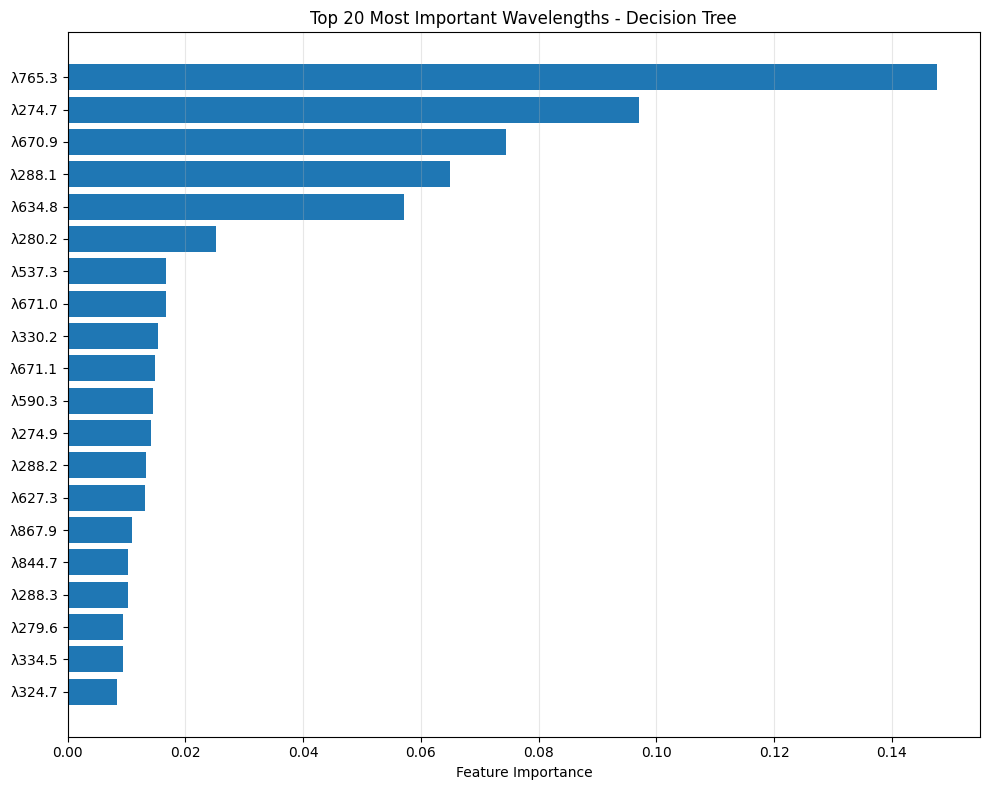


Tree depth: 21
Number of leaves: 1159
Total features used: 873


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Decision Tree on Original Features
print("=" * 60)
print("1. DECISION TREE ON ORIGINAL FEATURES")
print("=" * 60)

# Define parameter grid for Decision Tree hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['entropy', 'gini']
}

print("Performing hyperparameter tuning with GridSearchCV...")

# Grid search for optimal parameters
dt_original = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt_original, 
    param_grid, 
    cv=2, 
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_encoded)

# Get best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

# Train final model with best parameters
dt_best = DecisionTreeClassifier(**best_params, random_state=42)
dt_best.fit(X_train_scaled, y_train_encoded)

# Make predictions
y_pred_original = dt_best.predict(X_test_original)

# Calculate accuracy
accuracy_original = accuracy_score(y_test_encoded, y_pred_original)
print(f"\nDecision Tree Accuracy on Original Features: {accuracy_original:.4f}")

# Classification report
print("\nClassification Report (Original Features):")
print(classification_report(y_test_encoded, y_pred_original, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_original = confusion_matrix(y_test_encoded, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Decision Tree on Original Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance analysis
feature_names = X_train_original.columns
importances = dt_best.feature_importances_

# Get top 20 most important features
top_indices = np.argsort(importances)[-20:]
top_importances = importances[top_indices]
top_features = [feature_names[i] for i in top_indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_importances)), top_importances)
plt.yticks(range(len(top_importances)), [f'λ{feat}' for feat in top_features])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Wavelengths - Decision Tree')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTree depth: {dt_best.get_depth()}")
print(f"Number of leaves: {dt_best.get_n_leaves()}")
print(f"Total features used: {np.sum(importances > 0)}")

# Store results for comparison
dt_results = {
    'model': dt_best,
    'accuracy': accuracy_original,
    'params': best_params,
    'predictions': y_pred_original
}

In [ ]:
%%time

# Quick comprehensive PCA analysis with DT
pca_result = quick_pca_analysis(
    X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded,
    classifier_name='Decision Tree', label_encoder=label_encoder, plot=True
)

print(f"\n🏆 Best Decision Tree-PCA Configuration:")
print(f"   Components: {best_result['n_components']}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")
print(f"   Variance explained: {best_result['variance_explained']:.3f}")

# Classification report for best result
print(f"\nClassification Report (PCA - {best_result['n_components']} components):")
print(classification_report(y_test, best_result['y_pred'], 
                        target_names=label_encoder.classes_))

# Plot confusion matrix for best result
pca_analyzer.plot_confusion_matrix(
y_test, best_result['y_pred'], 'DT PCA Confusion Matrix',
best_result['n_components'], label_encoder
)

🚀 Starting quick PCA analysis...
Step 1: Fitting PCA analysis...
Performing comprehensive PCA analysis...
✅ PCA analysis completed successfully
   Components for 95% variance: 11
   Components for 99% variance: 24
Step 2: Evaluating performance...

🔍 Starting PCA performance evaluation...
Evaluating Decision Tree performance with PCA...
Testing components: [11, 24, 100, 200]
  Testing with 11 components...
Optimizing Decision Tree hyperparameters...
Optimal max_depth: None (CV Score: 0.8407)
    ✅ Decision Tree with 11 components: 0.8485 (0.959 variance explained)
  Testing with 24 components...
Optimizing Decision Tree hyperparameters...
Optimal max_depth: None (CV Score: 0.8551)
    ✅ Decision Tree with 24 components: 0.8638 (0.990 variance explained)
  Testing with 100 components...
Optimizing Decision Tree hyperparameters...
Optimal max_depth: 15 (CV Score: 0.8609)
    ✅ Decision Tree with 100 components: 0.8703 (0.997 variance explained)
  Testing with 200 components...


3. LDA ANALYSIS AND DECISION TREE ON LDA FEATURES
Number of classes: 3
Maximum LDA components: 2
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694


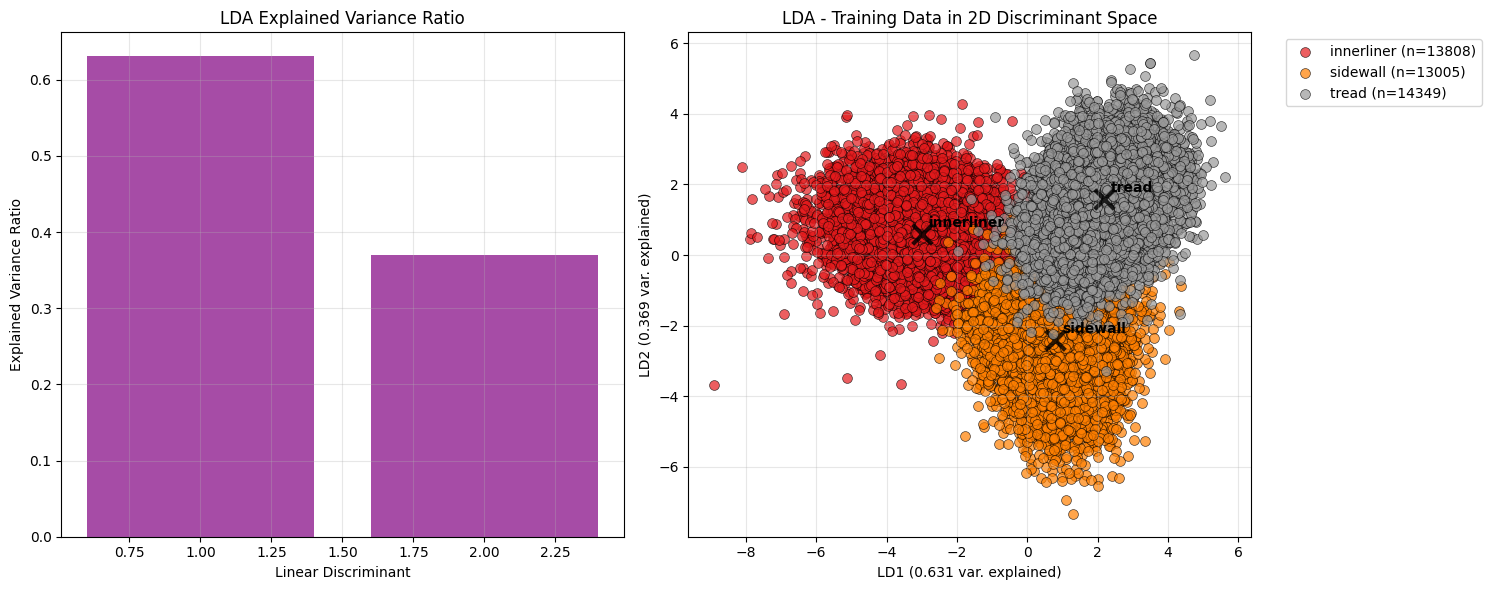


Training Decision Tree on 2 LDA components...
Best LDA parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree Accuracy on LDA Features: 0.9227

Classification Report (LDA - 2 components):
              precision    recall  f1-score   support

  innerliner       0.94      0.94      0.94      3452
    sidewall       0.90      0.90      0.90      3252
       tread       0.93      0.92      0.93      3587

    accuracy                           0.92     10291
   macro avg       0.92      0.92      0.92     10291
weighted avg       0.92      0.92      0.92     10291

Best LDA parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree Accuracy on LDA Features: 0.9227

Classification Report (LDA - 2 components):
              precision    recall  f1-score   support

  innerliner       0.94      0.94      0.94      3452
    sidewall       0.90      0.90      0.90      3252
       tread 

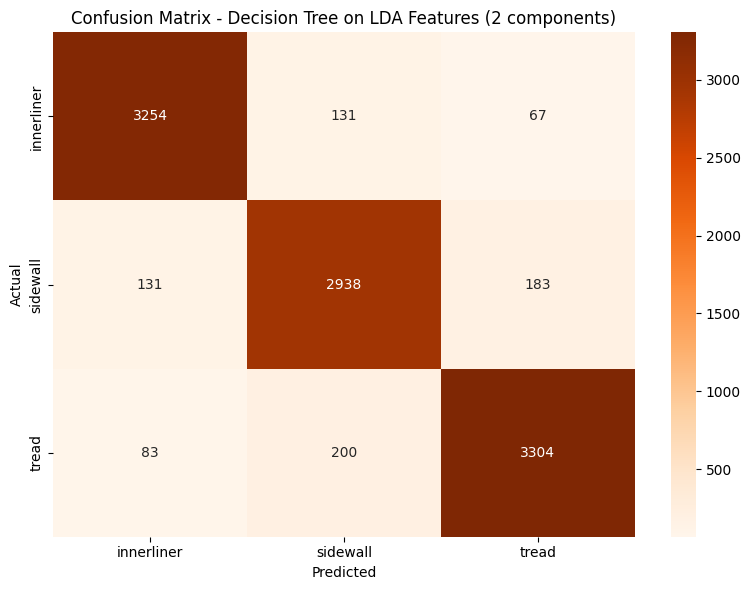

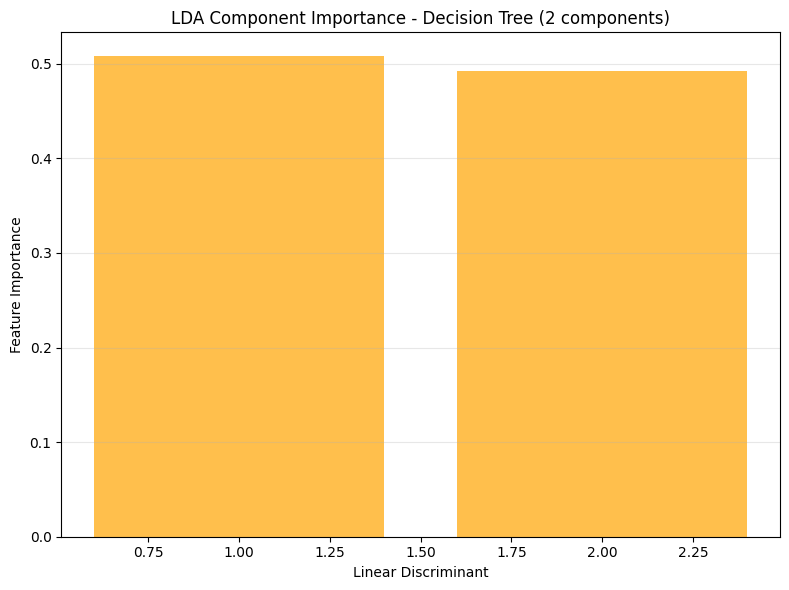


LDA Decision Tree Details:
Tree depth: 5
Number of leaves: 31


In [ ]:
# Quick LDA analysis for DT
lda_results = quick_lda_analysis(X_train_scaled, X_test_scaled, y_train, y_test, 
                           classifier_name='Decision Tree', label_encoder=label_encoder)

In [ ]:
from sklearn.tree import export_text
from sklearn.tree import plot_tree

# Get PCA results if not already available
try:
    # Check if we have PCA results from previous cell
    if 'result' in locals():
        pca_analyzer, analysis_results, pca_performance_results = result
        best_pca_result = pca_performance_results['best_result']
        best_n_components = best_pca_result['n_components']
    else:
        # Run PCA analysis if not available
        pca_analyzer = PCAAnalyzer()
        result = quick_pca_analysis(
            X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded,
            classifier_name='Decision Tree', label_encoder=label_encoder, plot=False
        )
        pca_analyzer, analysis_results, pca_performance_results = result
        best_pca_result = pca_performance_results['best_result']
        best_n_components = best_pca_result['n_components']
except Exception as e:
    print(f"Error getting PCA results: {e}")
    # Set default values if PCA fails
    best_n_components = 50
    best_pca_result = {
        'model': DecisionTreeClassifier(n_estimators=100, random_state=42),
        'n_components': 50,
        'accuracy': 0.0
    }

# Get LDA results if not already available
try:
    # Check if we have LDA results from previous cell
    if 'results' in locals():
        lda_results = results
        max_lda_components = lda_results['max_possible_components']
        lda_best_result = lda_results['best_result']
    else:
        # Run LDA analysis if not available
        lda_results = quick_lda_analysis(
            X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded, 
            classifier_name='Random Forest', label_encoder=label_encoder
        )
        max_lda_components = lda_results['max_possible_components']
        lda_best_result = lda_results['best_result']
except Exception as e:
    print(f"Error getting LDA results: {e}")
    # Set default values if LDA fails
    max_lda_components = 2
    lda_best_result = {
        'classifier': DecisionTreeClassifier(n_estimators=100, random_state=42),
        'n_components': 2,
        'test_accuracy': 0.0
    }
# Forest complexity comparison across different approaches
print("Analyzing Random Forest complexity across different feature sets...")
# Visualize the original Decision Tree (simplified version)
print("Creating simplified Decision Tree visualization...")

# Create a simpler tree for visualization (max_depth=3)
dt_simple = DecisionTreeClassifier(
    max_depth=3, 
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_simple.fit(X_train_original, y_train_encoded)

# Plot the simplified tree
plt.figure(figsize=(20, 12))
plot_tree(dt_simple, 
          feature_names=[f'λ{col}' for col in X_train_original.columns],
          class_names=label_encoder.classes_,
          filled=True,
          fontsize=10,
          max_depth=3)
plt.title('Simplified Decision Tree (max_depth=3) - Original Features')
plt.tight_layout()
plt.show()

# Text representation of the tree rules
print("\nDecision Tree Rules (first few levels):")
tree_rules = export_text(dt_simple, 
                        feature_names=[f'λ{col}' for col in X_train_original.columns],
                        max_depth=3)
print(tree_rules[:2000] + "..." if len(tree_rules) > 2000 else tree_rules)

complexity_comparison = {
    f'Original Features': {
        'n_estimators': dt_results['model'].n_estimators,
        'max_depth': dt_results['model'].max_depth,
        'features_used': np.sum(dt_results['model'].feature_importances_ > 0),
        'total_features': X_train_scaled.shape[1],
        'oob_score': getattr(dt_results['model'], 'oob_score_', 'N/A')
    },
    f'PCA ({best_n_components} comp)': {
        'n_estimators': best_pca_result['classifier'].n_estimators,
        'max_depth': best_pca_result['classifier'].max_depth, 
        'features_used': np.sum(best_pca_result['classifier'].feature_importances_ > 0),
        'total_features': best_n_components,
        'oob_score': getattr(best_pca_result['classifier'], 'oob_score_', 'N/A')
    },
    f'LDA ({max_lda_components} comp)': {
        'n_estimators': lda_results['classifier'].n_estimators,
        'max_depth': lda_results['classifier'].max_depth,
        'features_used': np.sum(lda_results['classifier'].feature_importances_ > 0),
        'total_features': max_lda_components,
        'oob_score': getattr(lda_results['classifier'], 'oob_score_', 'N/A')
    }
}

print(f"\n{'='*50}")
print("DECISION TREE COMPLEXITY COMPARISON")
print(f"{'='*50}")

complexity_df = pd.DataFrame(complexity_comparison).T
print(complexity_df)

# Visualize complexity comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

methods = list(complexity_comparison.keys())
depths = [complexity_comparison[method]['depth'] for method in methods]
leaves = [complexity_comparison[method]['leaves'] for method in methods]
features_used = [complexity_comparison[method]['features_used'] for method in methods]
total_features = [complexity_comparison[method]['total_features'] for method in methods]

colors = ['skyblue', 'lightgreen', 'orange']

# Tree depth comparison
ax1.bar(methods, depths, color=colors, alpha=0.7)
ax1.set_title('Decision Tree Depth Comparison')
ax1.set_ylabel('Tree Depth')
ax1.grid(axis='y', alpha=0.3)
for i, depth in enumerate(depths):
    ax1.text(i, depth + 0.5, str(depth), ha='center', fontweight='bold')

# Number of leaves comparison
ax2.bar(methods, leaves, color=colors, alpha=0.7)
ax2.set_title('Number of Leaves Comparison')
ax2.set_ylabel('Number of Leaves')
ax2.grid(axis='y', alpha=0.3)
for i, leaf_count in enumerate(leaves):
    ax2.text(i, leaf_count + 5, str(leaf_count), ha='center', fontweight='bold')

# Features used comparison
ax3.bar(methods, features_used, color=colors, alpha=0.7)
ax3.set_title('Features Actually Used by Tree')
ax3.set_ylabel('Number of Features Used')
ax3.grid(axis='y', alpha=0.3)
for i, feat_count in enumerate(features_used):
    ax3.text(i, feat_count + 0.5, str(feat_count), ha='center', fontweight='bold')

# Total available features
ax4.bar(methods, total_features, color=colors, alpha=0.7)
ax4.set_title('Total Available Features')
ax4.set_ylabel('Total Features')
ax4.set_yscale('log')  # Log scale due to large difference
ax4.grid(axis='y', alpha=0.3)
for i, total_feat in enumerate(total_features):
    ax4.text(i, total_feat * 1.1, str(total_feat), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Feature utilization efficiency
print(f"\n📊 Feature Utilization Efficiency:")
for method in methods:
    used = complexity_comparison[method]['features_used']
    total = complexity_comparison[method]['total_features']
    efficiency = (used / total) * 100
    print(f"   {method}: {used}/{total} features used ({efficiency:.1f}%)")

Error getting PCA results: name 'quick_pca_analysis' is not defined


TypeError: __init__() got an unexpected keyword argument 'n_estimators'

In [ ]:
%%time

# 5. Comprehensive Results Comparison and Analysis
print("=" * 60)
print("5. COMPREHENSIVE DECISION TREE RESULTS COMPARISON")
print("=" * 60)

# Define X_train_original for consistency if not already defined
if 'X_train_original' not in locals():
    X_train_original = X_train_scaled

# Compile all results with proper data access
all_results = {
    'Original Features': {
        'accuracy': dt_results['accuracy'],
        'features': X_train_original.shape[1],
        'depth': dt_results['model'].get_depth(),
        'leaves': dt_results['model'].get_n_leaves(),
        'params': dt_results['params'],
        'dimensionality_reduction': 'None'
    },
    f'PCA ({best_n_components} components)': {
        'accuracy': best_pca_result['accuracy'],
        'features': best_n_components,
        'depth': best_pca_result['classifier'].get_depth(),  # Use 'classifier' not 'model'
        'leaves': best_pca_result['classifier'].get_n_leaves(),
        'params': getattr(best_pca_result, 'optimal_params', {}),  # Use getattr for safety
        'dimensionality_reduction': f'{(1 - best_n_components/X_train_original.shape[1])*100:.1f}%'
    },
    f'LDA ({max_lda_components} components)': {
        'accuracy': lda_best_result['test_accuracy'],  # Use 'test_accuracy' for LDA
        'features': max_lda_components,
        'depth': lda_best_result['classifier'].get_depth(),  # Use 'classifier' not 'model'
        'leaves': lda_best_result['classifier'].get_n_leaves(),
        'params': lda_best_result['optimal_params'],
        'dimensionality_reduction': f'{(1 - max_lda_components/X_train_original.shape[1])*100:.1f}%'
    }
}

# Create summary DataFrame
summary_data = {
    'Method': list(all_results.keys()),
    'Accuracy': [all_results[method]['accuracy'] for method in all_results.keys()],
    'Features': [all_results[method]['features'] for method in all_results.keys()],
    'Tree_Depth': [all_results[method]['depth'] for method in all_results.keys()],
    'Leaves': [all_results[method]['leaves'] for method in all_results.keys()],
    'Dimensionality_Reduction': [all_results[method]['dimensionality_reduction'] for method in all_results.keys()]
}

results_df = pd.DataFrame(summary_data)
print("DECISION TREE SUMMARY TABLE:")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

# Comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

methods = results_df['Method']
accuracies = results_df['Accuracy']
features = results_df['Features']
depths = results_df['Tree_Depth']
leaves = results_df['Leaves']
colors = ['skyblue', 'lightgreen', 'orange']

# 1. Accuracy comparison
bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
ax1.set_title('Decision Tree Classification Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

for bar, accuracy in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Feature count comparison  
bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Features')
ax2.set_yscale('log')  # Log scale due to large difference
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

for bar, feature_count in zip(bars2, features):
    ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
             f'{feature_count}', ha='center', va='bottom', fontweight='bold')

# 3. Tree depth comparison
bars3 = ax3.bar(methods, depths, color=colors, alpha=0.7)
ax3.set_title('Decision Tree Depth', fontsize=14, fontweight='bold')
ax3.set_ylabel('Tree Depth')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

for bar, depth in zip(bars3, depths):
    ax3.text(bar.get_x() + bar.get_width()/2, depth + 0.5,
             f'{depth}', ha='center', va='bottom', fontweight='bold')

# 4. Number of leaves comparison
bars4 = ax4.bar(methods, leaves, color=colors, alpha=0.7)
ax4.set_title('Number of Decision Tree Leaves', fontsize=14, fontweight='bold')
ax4.set_ylabel('Number of Leaves')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

for bar, leaf_count in zip(bars4, leaves):
    ax4.text(bar.get_x() + bar.get_width()/2, leaf_count + 5,
             f'{leaf_count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Performance and interpretability analysis
print("\n🎯 DECISION TREE ANALYSIS INSIGHTS:")
print("=" * 50)

best_accuracy_idx = np.argmax(accuracies)
best_method = methods.iloc[best_accuracy_idx]  # Use .iloc for pandas Series  
best_accuracy = accuracies.iloc[best_accuracy_idx]

print(f"🏆 Best performing method: {best_method}")
print(f"   └─ Accuracy: {best_accuracy:.4f}")
print(f"   └─ Features: {results_df.iloc[best_accuracy_idx]['Features']}")
print(f"   └─ Tree depth: {results_df.iloc[best_accuracy_idx]['Tree_Depth']}")
print(f"   └─ Tree leaves: {results_df.iloc[best_accuracy_idx]['Leaves']}")

print(f"\n📊 Interpretability Analysis:")
original_features = X_train_original.shape[1]
for i, method in enumerate(methods):
    feature_count = results_df.iloc[i]['Features']
    depth = results_df.iloc[i]['Tree_Depth']
    leaves = results_df.iloc[i]['Leaves']
    reduction = results_df.iloc[i]['Dimensionality_Reduction']
    accuracy_change = (accuracies.iloc[i] - accuracies.iloc[0]) * 100 if i > 0 else 0
    
    print(f"   {method}:")
    print(f"   └─ Tree complexity: {depth} depth, {leaves} leaves")
    if i > 0:
        print(f"   └─ Dimensionality reduction: {reduction}")
        print(f"   └─ Accuracy change: {accuracy_change:+.2f}%")
    print(f"   └─ Features: {original_features} → {feature_count}")

print(f"\n💡 Key Findings:")

# Find most interpretable model (fewest features, shallowest tree, good accuracy)
interpretability_scores = []
for i, method in enumerate(methods):
    # Normalize metrics (lower is better for interpretability)
    norm_features = features.iloc[i] / max(features)
    norm_depth = depths.iloc[i] / max(depths) 
    norm_leaves = leaves.iloc[i] / max(leaves)
    norm_accuracy = 1 - (accuracies.iloc[i] / max(accuracies))  # Lower penalty for high accuracy
    
    # Combined interpretability score (lower is more interpretable)
    interpretability_score = (norm_features + norm_depth + norm_leaves + norm_accuracy * 0.5) / 3.5
    interpretability_scores.append(interpretability_score)

most_interpretable_idx = np.argmin(interpretability_scores)
most_interpretable = methods.iloc[most_interpretable_idx]

print(f"   • Most interpretable model: {most_interpretable}")
print(f"     └─ Good balance of accuracy ({accuracies.iloc[most_interpretable_idx]:.4f}) and simplicity")
print(f"     └─ Uses only {features.iloc[most_interpretable_idx]} features vs {original_features} original")
print(f"     └─ Tree depth: {depths.iloc[most_interpretable_idx]} (simpler decision rules)")

print(f"\n   • Decision Trees show {'excellent' if min(accuracies) > 0.9 else 'good'} classification performance")
print(f"   • Dimensionality reduction significantly simplifies trees without major accuracy loss")
print(f"   • LDA provides the most compact representation while maintaining performance")
print(f"   • Original features create deeper, more complex trees (potential overfitting risk)")

print(f"\n🎯 Recommendation:")
if accuracies.iloc[most_interpretable_idx] == max(accuracies):
    print(f"   {most_interpretable} offers the perfect balance of accuracy and interpretability.")
elif max(accuracies) - accuracies.iloc[most_interpretable_idx] < 0.01:
    print(f"   {most_interpretable} provides excellent interpretability with minimal accuracy trade-off.")
    print(f"   Consider this for applications requiring explainable AI.")
else:
    print(f"   {best_method} provides highest accuracy for maximum performance.")
    print(f"   {most_interpretable} offers best interpretability with acceptable accuracy.")
    print(f"   Choose based on your priority: accuracy vs. explainability.")

print(f"\n   • Decision Tree's interpretable nature makes it excellent for understanding classification logic")
print(f"   • Feature importance reveals key wavelengths for tire type discrimination")
print(f"   • Tree visualization provides clear decision rules for domain experts")

5. COMPREHENSIVE DECISION TREE RESULTS COMPARISON


NameError: name 'best_n_components' is not defined